This file is meant to find a way to quantify how discretization invariant a model is. The goal is some function that takes the losses as input and returns a single number quantifying how discretization invariant the model is. For now it will the input losses are for 2D models trained at N = 192, 9 resolutions tested and resolution step = 16.

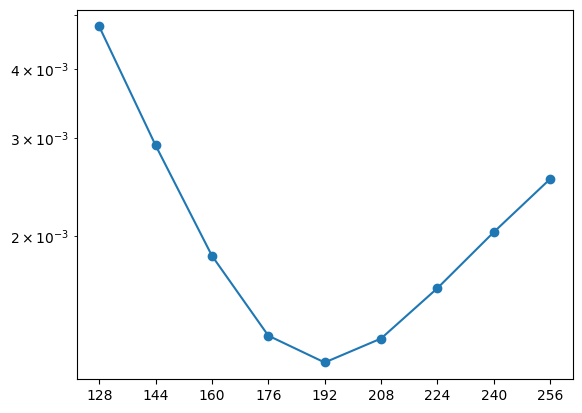

k8 loss: 0.508
k16 loss: 3.482


In [16]:
import matplotlib.pyplot as plt 
import numpy as np

FNO_k8_loss = [0.00477402, 0.00291291, 0.00184039, 0.00132027, 0.00118091, 0.00130451,
        0.00160813, 0.00203017, 0.00253239]

FNO_k16_loss = [3.19471133e-03, 1.56762974e-03, 6.10692441e-04, 1.42305543e-04,
                1.15199866e-05, 1.08377670e-04, 3.53756824e-04, 6.92857297e-04,
                1.08979642e-03]

train_idx = 4

perfect_loss = [0.00118091]*9


resolutions = np.arange(128, 257, 16)

plt.plot(resolutions, FNO_k8_loss, marker = "o")
plt.yscale("log")
plt.xticks(resolutions, resolutions)
plt.show()

def DI_log_mean_abs(loss, train_idx, eps = 1e-12):
    loss = np.asarray(loss, dtype = float)
    ref = loss[train_idx]
    return np.mean(np.abs(np.log(loss + eps) - np.log(ref + eps)))

DI_val_k8 = DI_log_mean_abs(FNO_k8_loss, train_idx)
DI_val_k16 = DI_log_mean_abs(FNO_k16_loss, train_idx)


print(f"k8 loss: {DI_val_k8:.3f}")
print(f"k16 loss: {DI_val_k16:.3f}")

In [24]:
print(np.random.randn())

1.4489006362449262
